# Matplotlib

[matplotlib documentation](https://matplotlib.org/stable/users/index.html)

[matplotlib plot types](https://matplotlib.org/stable/plot_types/index.html)

- [Axes](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html)
- [Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot)

In [2]:
# from matplotlib.dates import ConciseDateFormatter
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import numpy as np
import datetime

### Style sheets
plt.style.use('dark_background')
# plt.style.use('grayscale')
# plt.style.use('petroff10')
# plt.style.use('fivethirtyeight')
# plt.style.use('Solarize_Light2')

dt_now = datetime.datetime.now()
dt_now_formatted = dt_now.strftime("%Y-%m-%d | %H:%M")
print(f">>> loaded on {dt_now_formatted}")

>>> loaded on 2026-07-29 | 15:43


### plot (Line plot)

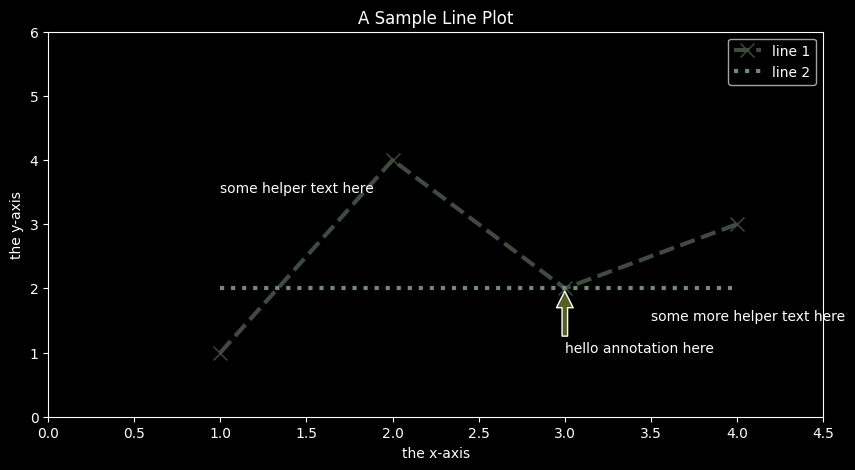

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
x_1, y_1 = [1, 2, 3, 4], [1, 4, 2, 3]
x_2, y_2 = [1, 2, 3, 4], [2, 2, 2, 2]

ax.plot(x_1, y_1, color = "#3f4b3f", label = "line 1", linewidth = 3, linestyle = "--", marker = "x", markersize = 10)
ax.plot(x_2, y_2, color = "#6d8c77", label = "line 2", linewidth = 3, linestyle = ":")

# Titles, labels, legend
ax.set_title("A Sample Line Plot")
ax.set_xlabel("the x-axis")
ax.set_ylabel("the y-axis")
ax.legend()

# Set x and y axes
ax.set(xlim = (0, 4.5), ylim = (0, 6))

# Add text
# ax.text(x-value, y-value, "your_text")
ax.text(1, 3.5, "some helper text here")
ax.text(3.5, 1.5, "some more helper text here")

# Add annotations
ax.annotate('hello annotation here', xy = (3, 2), xytext=(3, 1), arrowprops = dict(facecolor = "#565f26", shrink = 0.05))

# Enable grid
ax.grid(False)

plt.show()

### Plot with time and dates

In [3]:
log_path = "/home/hank/code_workbench/_git_repo/telegram-pinboard/_data/bedtime_log.txt"

with open(log_path, "r") as log:
    records = log.readlines()

data = records[-31:]

date_data, time_data = list(), list()
for entry in data:
    date_str, time_str = entry.split(",")
    date_data.append(date_str)
    time_data.append(datetime.time(int(time_str[:2]), int(time_str[2:])))

x_data = np.array(date_data, dtype = 'datetime64[D]')
y_data = [datetime.datetime.combine(datetime.date(1997, 7, 30), t) for t in time_data]

print(x_data[0], type(x_data[0]))

2026-06-28 <class 'numpy.datetime64'>


In [4]:
x_data = np.arange('2026-07-01', '2026-07-28', dtype = 'datetime64[D]')
print(x_data[0], type(x_data[0]))

2026-07-01 <class 'numpy.datetime64'>


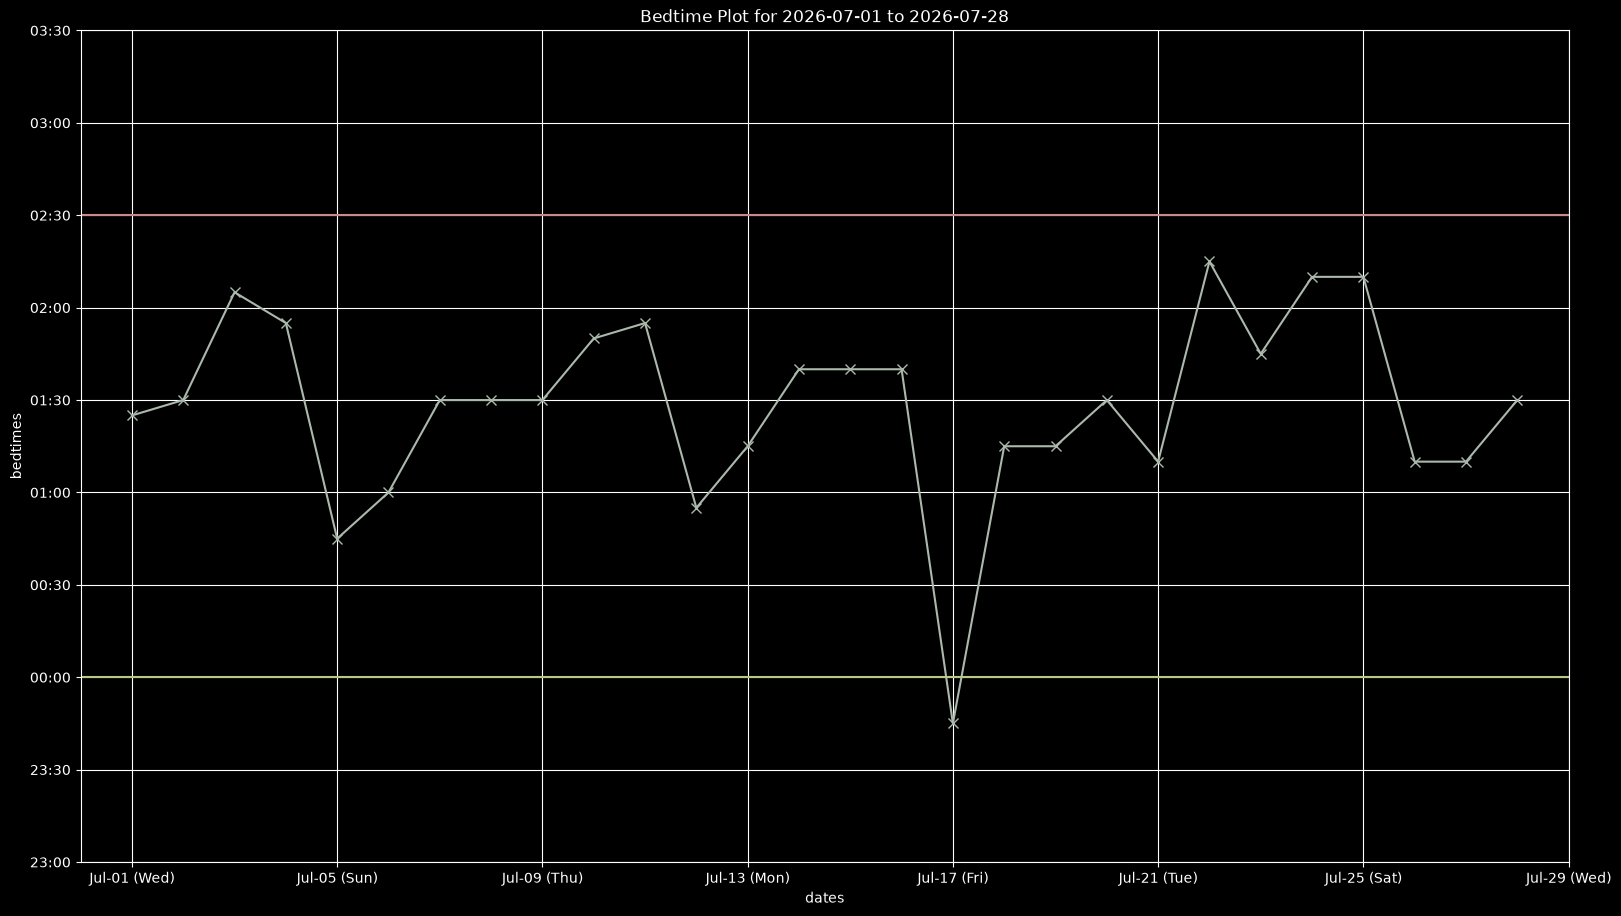

In [34]:
# 1920 x 1080 pixels
fig, ax = plt.subplots(figsize = (19.2, 10.8))

# Using log data
log_path = "/home/hank/code_workbench/_git_repo/telegram-pinboard/_data/bedtime_log.txt"
with open(log_path, "r") as log:
    records = log.readlines()

# Number of records to use
data = records[-28:]

date_data, time_data = list(), list()
for entry in data:
    date_str, time_str = entry.split(",")
    date_data.append(date_str)
    time_data.append(datetime.time(int(time_str[:2]), int(time_str[2:])))

# x-axis data = date of bedtime
x_data = np.array(date_data, dtype = 'datetime64[D]')

# y-axis data = bedtime
# If time is before 00:00, combine with 1997-07-29
# If time is on or after 00:00, combine with 1997-07-30
y_data = [datetime.datetime.combine(datetime.date(1997, 7, 29), t) if 12 <= t.hour <= 23 else datetime.datetime.combine(datetime.date(1997, 7, 30), t) for t in time_data]

# Plot
ax.plot(x_data, y_data, color = "#abb8ac", marker = "x", markersize = 7)
ax.axhline(y = datetime.datetime(1997, 7, 30, 2, 30, 0), label = "danger", color = "#CC898B", linestyle = "-")
ax.axhline(y = datetime.datetime(1997, 7, 30, 0, 0, 0), label = "ok", color = "#b8c984", linestyle = "-")

# Define axis limits
ax.set_xlim(left = x_data[0] - np.timedelta64(1, 'D'), right = x_data[-1] + np.timedelta64(1, 'D'))
ax.set_ylim(bottom = datetime.datetime(1997, 7, 29, 23, 0), top = datetime.datetime(1997, 7, 30, 3, 30))

# Date and time formatter for axes tickers
date_formatter = mdates.DateFormatter('%b-%d (%a)')
ax.xaxis.set_major_formatter(date_formatter)
time_formatter = mdates.DateFormatter('%H:%M')
ax.yaxis.set_major_formatter(time_formatter)

# Titles, labels, grid
ax.set_title(f"Bedtime Plot for {x_data[0]} to {x_data[-1]}")
ax.set_xlabel("dates")
ax.set_ylabel("bedtimes")
ax.grid(True)

# save plot
# fig.savefig("bedtime_plot_test.png")

### Parts of a Figure

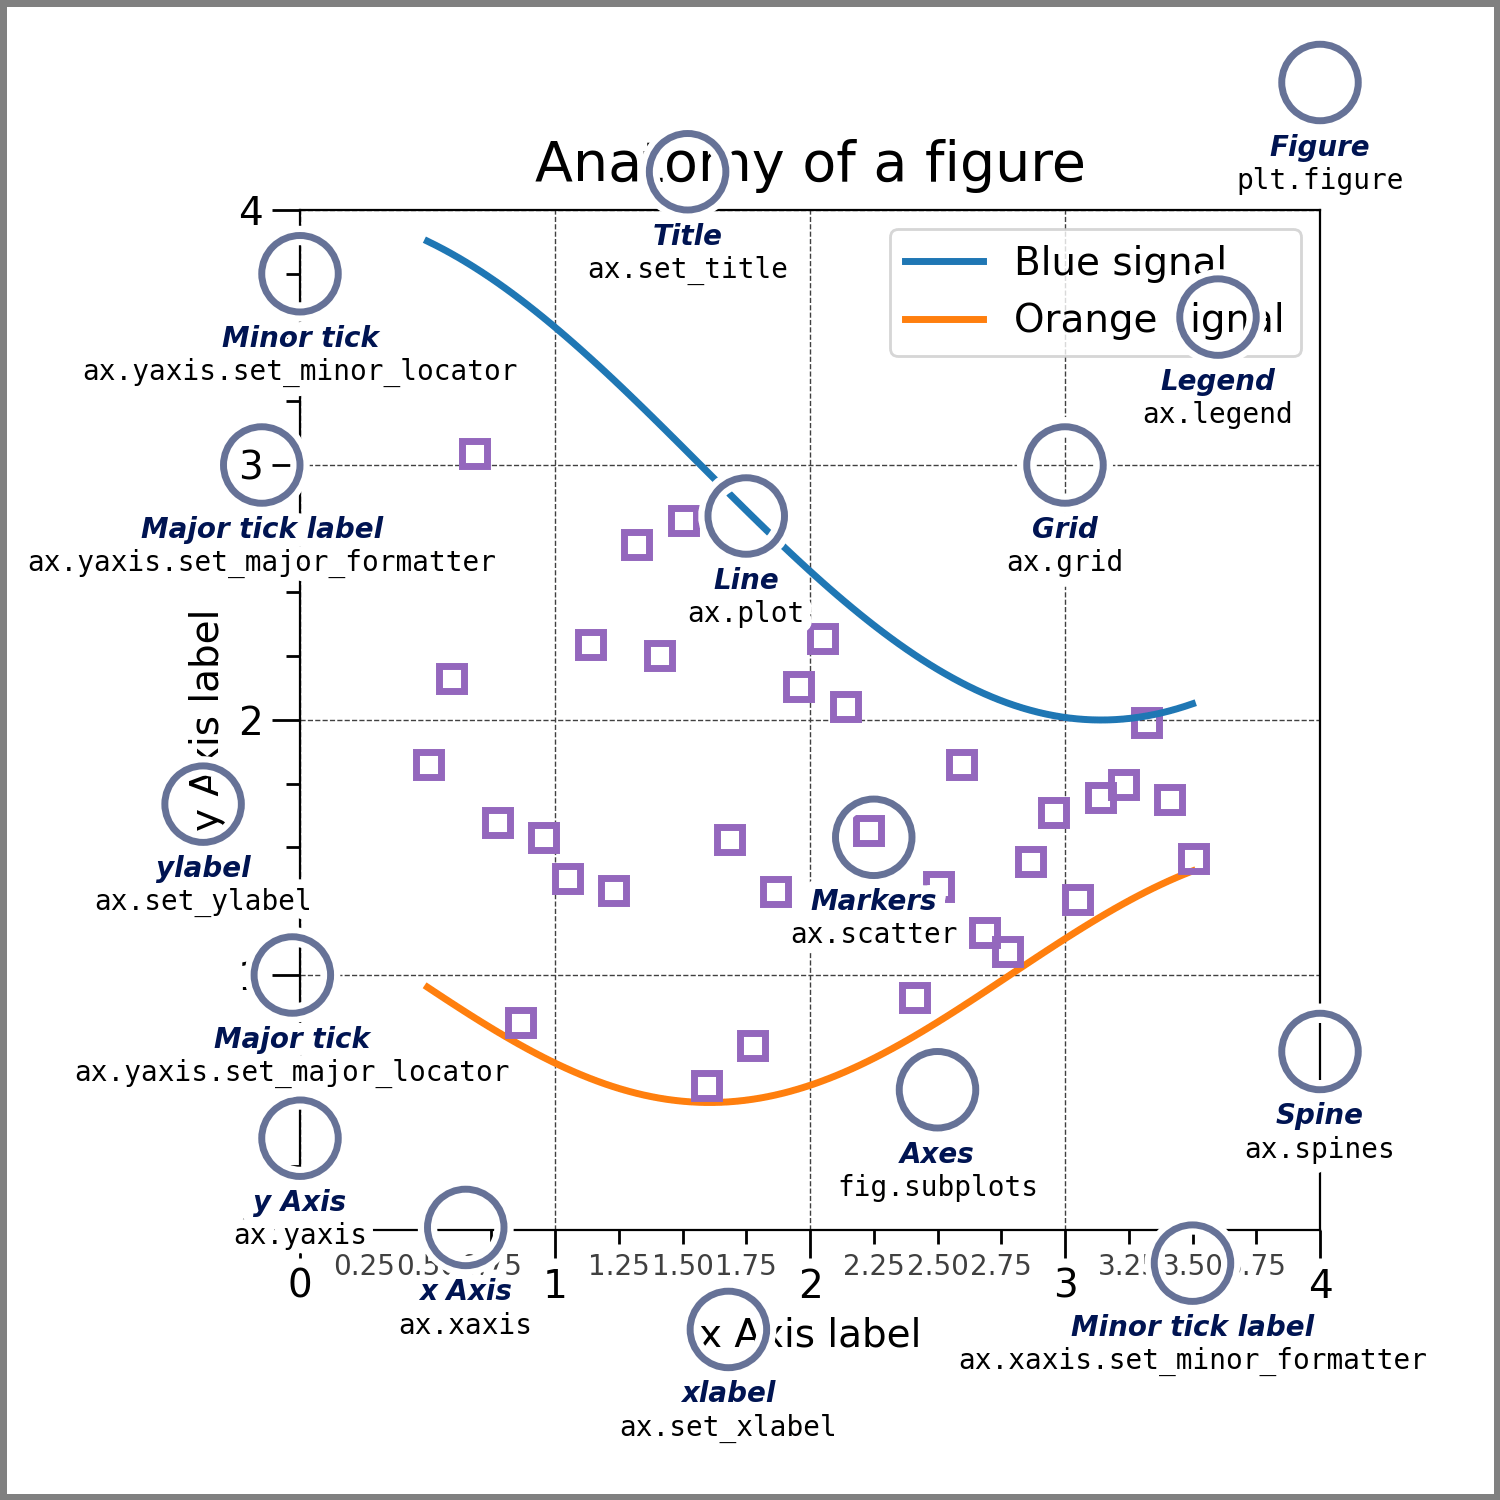

### Figure

In [9]:
# an empty figure with no Axes
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

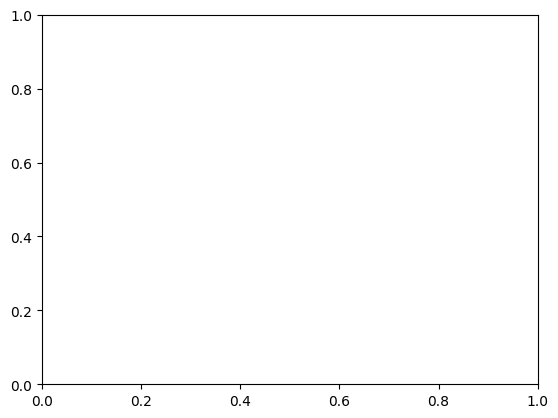

In [10]:
# a figure with a single Axes
fig, ax = plt.subplots()

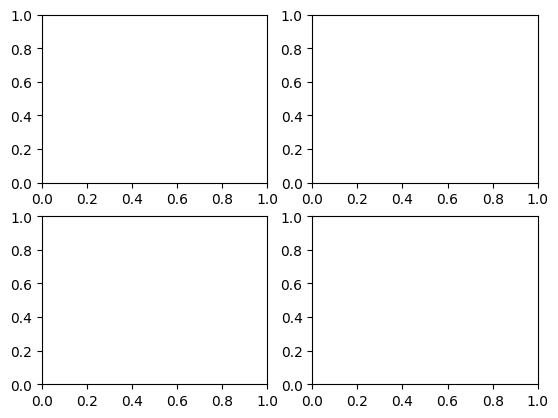

In [12]:
# a figure with a 2x2 grid of Axes
fig, axs = plt.subplots(2, 2)

Text(0.5, 1.0, 'right bottom plot')

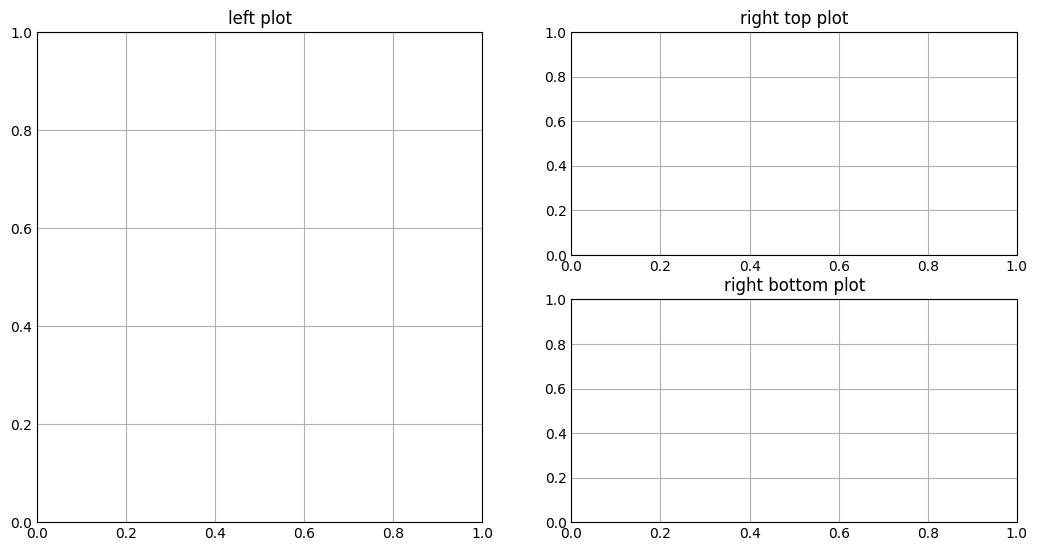

In [60]:
# a figure with one Axes on the left, and two on the right
fig, axs = plt.subplot_mosaic( [['left', 'right_top'], ['left', 'right_bottom']], figsize = (10, 5) )
axs['left'].set_title('left plot')
axs['right_top'].set_title('right top plot')
axs['right_bottom'].set_title('right bottom plot')

### declare function to reuse plots

In [ ]:
def plotter_1(ax, data1, data2, param_dict):
    out = ax.plot(data1, data2, **param_dict)
    return out

### Animated Plots

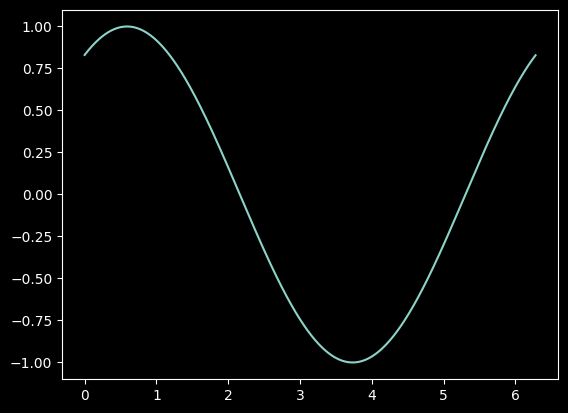

In [ ]:
fig, ax = plt.subplots()

x = np.arange(0, 2 * np.pi, 0.01)
line, = ax.plot(x, np.sin(x))

def animate(i):
    line.set_ydata(np.sin(x + i / 50))
    return line,

ani = animation.FuncAnimation(fig, animate, interval = 20, blit = True, save_count = 50)

writer = animation.PillowWriter(fps = 60, metadata = dict(artist = 'hnk'), bitrate = 1800)
ani.save("plot_animation_test.gif", writer = writer)

plt.show()

### stairs

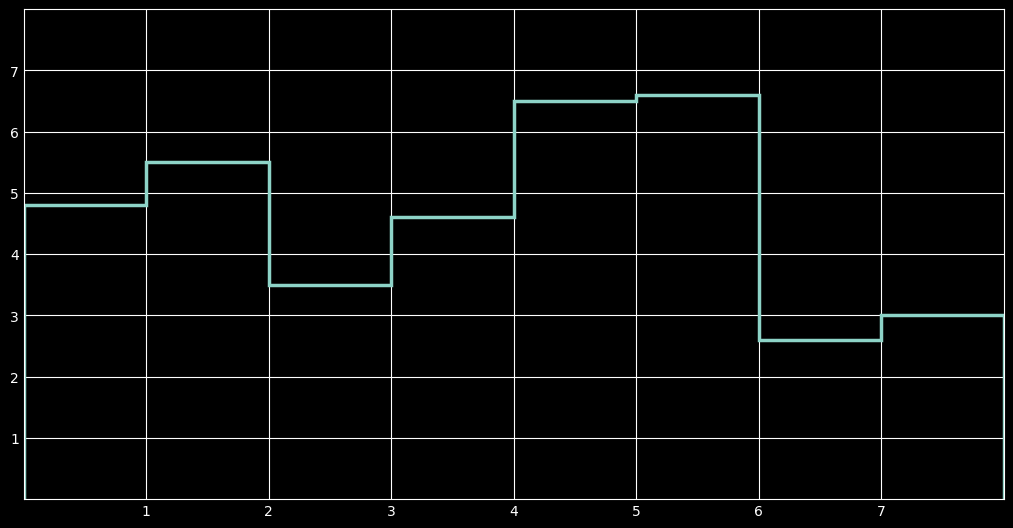

In [ ]:
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]
fig, ax = plt.subplots(figsize = (10, 5))
ax.stairs(y, linewidth = 2.5)
ax.set(xlim = (0, 8), xticks = np.arange(1, 8),
       ylim = (0, 8), yticks = np.arange(1, 8))

plt.show()